Dataset generado: 100000 registros con 15 variables.

Estadísticas descriptivas del dataset:
         customer_id            age  annual_income  account_balance  \
count  100000.000000  100000.000000  100000.000000    100000.000000   
mean    50000.500000      40.009880   41554.262100     22871.889410   
std     28867.657797      13.992178   21254.567301     16928.971045   
min         1.000000      18.000000   20000.000000      2001.000000   
25%     25000.750000      29.000000   25896.000000     11005.000000   
50%     50000.500000      40.000000   36269.000000     18658.500000   
75%     75000.250000      50.000000   50832.000000     29948.250000   
max    100000.000000      80.000000  200000.000000    193116.000000   

       num_transactions  avg_transaction_amount   credit_score      num_loans  \
count     100000.000000           100000.000000  100000.000000  100000.000000   
mean          30.667550               86.640519     683.770890       1.368410   
std            7.238184 

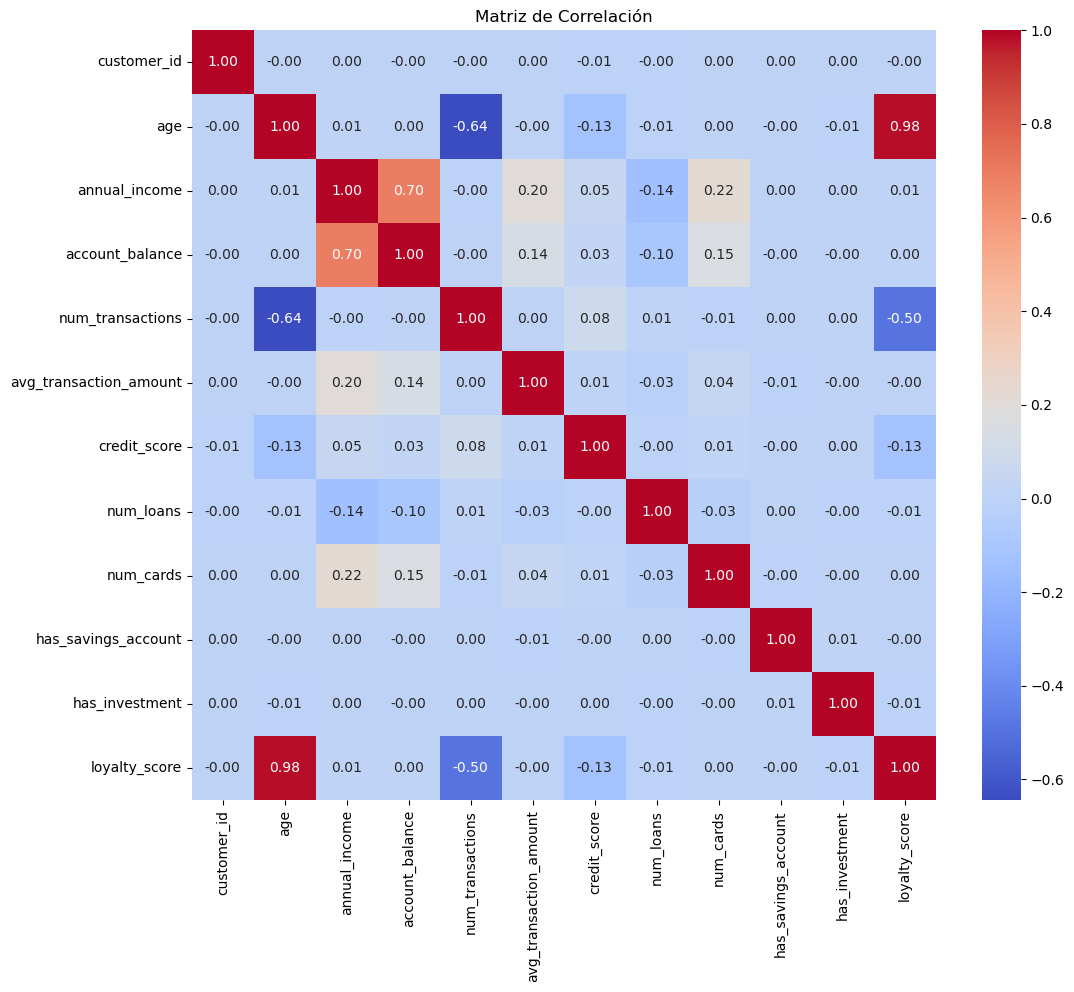

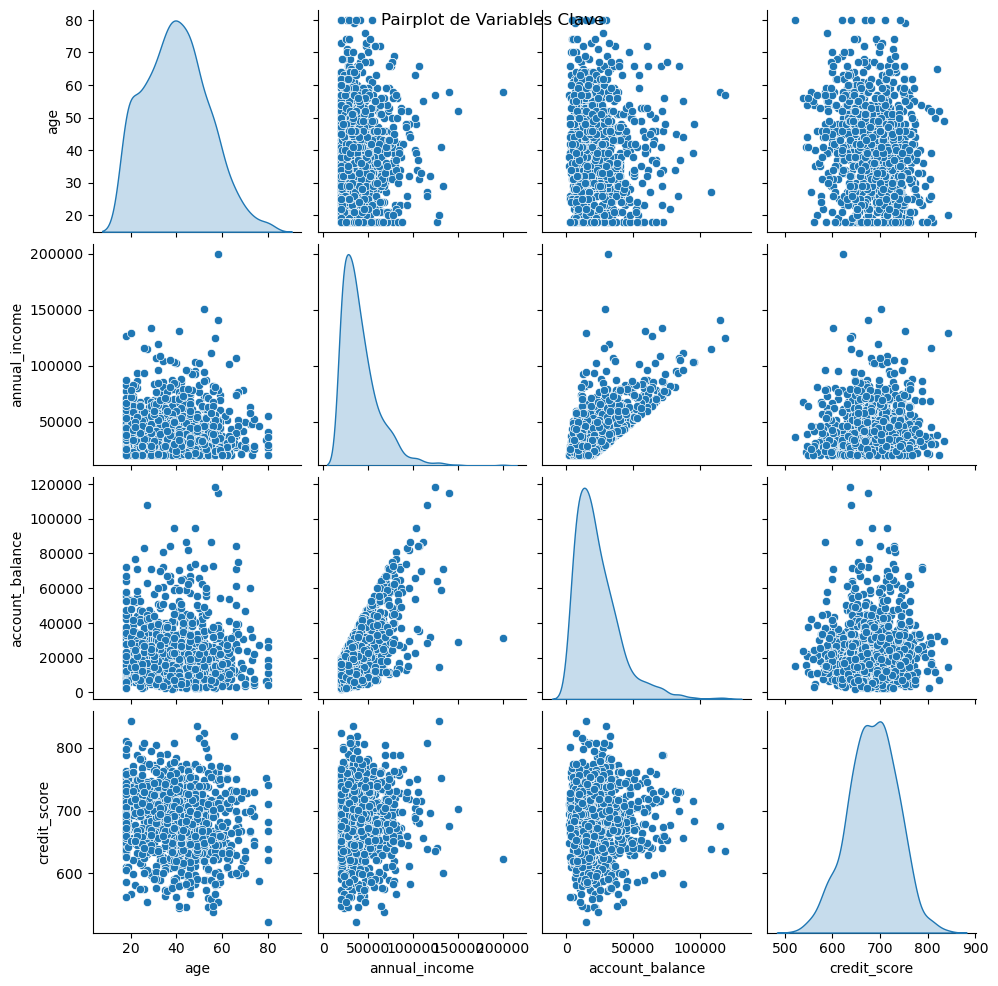

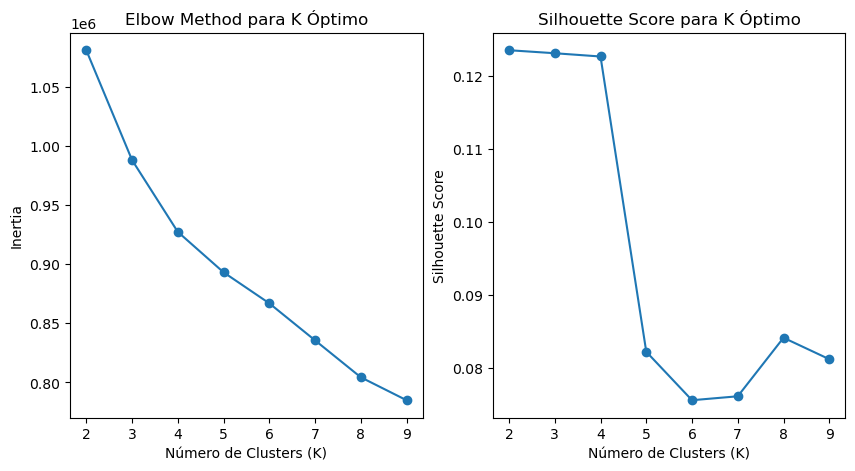


Distribución de Clientes por Cluster:
cluster
1    38300
0    32368
3    16371
2    12961
Name: count, dtype: int64


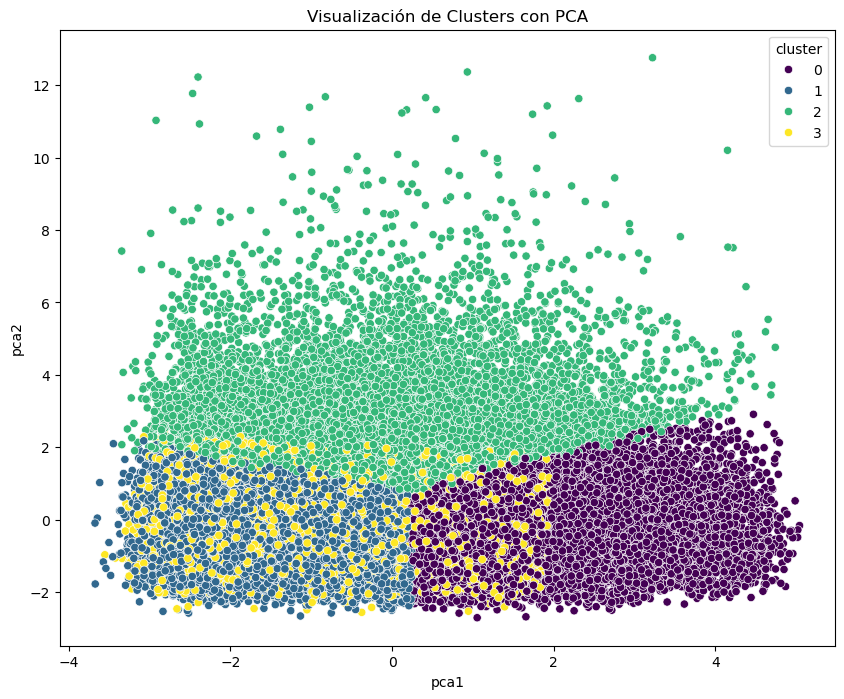


Perfiles Promedio por Cluster:
          age  annual_income  account_balance  num_transactions  \
cluster                                                           
0        1.00          -0.26            -0.25             -0.75   
1       -0.73          -0.30            -0.29              0.55   
2       -0.03           1.77             1.73              0.01   
3       -0.26          -0.19            -0.19              0.19   

         avg_transaction_amount  credit_score  num_loans  num_cards  \
cluster                                                               
0                         -0.09         -0.23       0.04      -0.08   
1                         -0.10          0.13       0.07      -0.10   
2                          0.61          0.13      -0.37       0.55   
3                         -0.06          0.04       0.03      -0.05   

         has_savings_account  has_investment  loyalty_score  
cluster                                                      
0             

In [1]:
import pandas as pd  # Para manipulación de DataFrames y datos estructurados
import numpy as np   # Para generación de datos sintéticos numéricos y operaciones matemáticas
import matplotlib.pyplot as plt  # Para visualizaciones básicas como gráficos de dispersión y elbow
import seaborn as sns  # Para gráficos avanzados y atractivos (e.g., heatmaps, pairplots)
from sklearn.preprocessing import StandardScaler  # Para escalar features numéricas (necesario en clustering)
from sklearn.cluster import KMeans  # Algoritmo principal para segmentación (K-Means)
from sklearn.decomposition import PCA  # Para reducción de dimensionalidad y visualización de clusters en 2D
from sklearn.metrics import silhouette_score  # Métrica para evaluar calidad de clusters (opcional para profesionalismo)
import warnings
warnings.filterwarnings('ignore')  # Ignorar warnings menores para salida limpia

# Paso 1: Generar un dataset sintético desde cero para segmentación de clientes bancarios
# Simularemos 100,000 clientes con más de 10 variables relevantes para banca.
# Variables clave para clustering por comportamiento:
# - customer_id: ID único (entero)
# - age: Edad (18-80 años)
# - gender: Género ('Male', 'Female', 'Other')
# - annual_income: Ingreso anual (USD, 20k-200k)
# - account_balance: Saldo en cuenta (0-500k)
# - num_transactions: Transacciones mensuales (0-100)
# - avg_transaction_amount: Monto promedio por transacción (50-5000 USD)
# - credit_score: Puntaje crediticio (300-850)
# - num_loans: Número de préstamos activos (0-5)
# - num_cards: Número de tarjetas (0-5)
# - has_savings_account: Cuenta de ahorros (0/1)
# - has_investment: Inversiones (0/1)
# - loyalty_score: Puntaje de lealtad (basado en antigüedad, 0-100)
# - region: Región geográfica ('North', 'South', 'East', 'West') - Para segmentación demográfica
# - preferred_channel: Canal preferido ('App', 'Branch', 'Online', 'ATM')
# No generamos target supervisado; clustering es no supervisado para descubrir segmentos.

def generate_banking_data(num_records=100000):
    """
    Genera dataset sintético de clientes bancarios para segmentación.
    - num_records: Número de registros (100,000 clientes).
    Retorna DataFrame con variables realistas para clustering.
    """
    np.random.seed(42)  # Reproducibilidad
    
    data = {}
    
    # ID único del cliente
    data['customer_id'] = np.arange(1, num_records + 1)
    
    # Edad: Distribución normal centrada en 40, std=15
    data['age'] = np.clip(np.random.normal(40, 15, num_records), 18, 80).astype(int)
    
    # Género: Distribución ponderada
    data['gender'] = np.random.choice(['Male', 'Female', 'Other'], num_records, p=[0.48, 0.48, 0.04])
    
    # Ingreso anual: Lognormal para simular distribución real (skewed)
    data['annual_income'] = np.clip(np.random.lognormal(mean=10.5, sigma=0.5, size=num_records), 20000, 200000).astype(int)
    
    # Saldo en cuenta: Correlacionado con ingreso (mayor ingreso → mayor saldo)
    data['account_balance'] = np.clip(data['annual_income'] * np.random.uniform(0.1, 1.0, num_records), 0, 500000).astype(int)
    
    # Transacciones mensuales: Poisson, más en jóvenes/digitales
    data['num_transactions'] = np.random.poisson(20 + (24 - data['age']/3), num_records)
    
    # Monto promedio por transacción: Correlacionado con ingreso
    data['avg_transaction_amount'] = np.clip(np.random.normal(data['annual_income']/1000, 100, num_records), 50, 5000)
    
    # Puntaje crediticio: Alto para ingresos altos, bajo para jóvenes
    data['credit_score'] = np.clip(np.random.normal(700 + (data['annual_income']/10000 - data['age']/2), 50, num_records), 300, 850).astype(int)
    
    # Número de préstamos: Bajo para bajos ingresos
    data['num_loans'] = np.random.poisson(1 + (data['annual_income'] < 50000)/2, num_records)
    data['num_loans'] = np.clip(data['num_loans'], 0, 5)
    
    # Número de tarjetas: Similar a préstamos
    data['num_cards'] = np.random.poisson(2 + (data['annual_income']/50000), num_records)
    data['num_cards'] = np.clip(data['num_cards'], 0, 5)
    
    # Cuenta de ahorros: Más probable en ingresos altos
    data['has_savings_account'] = np.random.choice([0, 1], num_records, p=[0.3, 0.7] if np.mean(data['annual_income']) > 50000 else [0.6, 0.4])
    
    # Inversiones: Solo para altos ingresos
    data['has_investment'] = np.random.choice([0, 1], num_records, p=[0.2, 0.8] if np.mean(data['annual_income']) > 100000 else [0.8, 0.2])
    
    # Puntaje de lealtad: Basado en edad y transacciones
    data['loyalty_score'] = np.clip(50 + data['age']/2 + data['num_transactions']/5, 0, 100).astype(int)
    
    # Región geográfica
    data['region'] = np.random.choice(['North', 'South', 'East', 'West'], num_records)
    
    # Canal preferido
    data['preferred_channel'] = np.random.choice(['App', 'Branch', 'Online', 'ATM'], num_records, p=[0.4, 0.2, 0.3, 0.1])
    
    df = pd.DataFrame(data)
    print(f"Dataset generado: {len(df)} registros con {len(df.columns)} variables.")
    return df

# Generar el dataset
bank_df = generate_banking_data(num_records=100000)

# Guardar como CSV (opcional)
bank_df.to_csv('bank_customers_segmentation.csv', index=False)

# Paso 2: Análisis Exploratorio de Datos (EDA)
# Resumen estadístico para entender distribución
print("\nEstadísticas descriptivas del dataset:")
print(bank_df.describe())

# Visualizar correlaciones (para identificar patrones)
numeric_cols = bank_df.select_dtypes(include=[np.number]).columns
corr_matrix = bank_df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

# Pairplot para variables clave (muestra pequeña para velocidad)
sns.pairplot(bank_df.sample(1000)[['age', 'annual_income', 'account_balance', 'credit_score']], diag_kind='kde')
plt.suptitle('Pairplot de Variables Clave')
plt.show()

# Paso 3: Preprocesamiento
# Codificar variables categóricas (One-Hot Encoding para gender, region, preferred_channel)
cat_cols = ['gender', 'region', 'preferred_channel']
bank_df = pd.get_dummies(bank_df, columns=cat_cols, drop_first=True)

# Escalar variables numéricas (K-Means es sensible a escalas)
num_cols = ['age', 'annual_income', 'account_balance', 'num_transactions', 'avg_transaction_amount', 
            'credit_score', 'num_loans', 'num_cards', 'has_savings_account', 'has_investment', 'loyalty_score']
scaler = StandardScaler()
bank_df[num_cols] = scaler.fit_transform(bank_df[num_cols])

# Seleccionar features para clustering (excluir ID)
X = bank_df.drop(columns=['customer_id'])

# Paso 4: Determinar número óptimo de clusters (K) con Elbow Method y Silhouette Score
inertia = []
silhouette_scores = []
k_range = range(2, 10)  # Probar de 2 a 9 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)  # Suma de cuadrados dentro de clusters
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Gráfico Elbow
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method para K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inertia')

# Gráfico Silhouette
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score para K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

# Elegir K óptimo (e.g., donde elbow se dobla o silhouette máximo; asumimos K=4 basado en típico)
optimal_k = 4  # Ajusta basado en gráficos

# Paso 5: Aplicar K-Means y Asignar Clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
bank_df['cluster'] = kmeans.fit_predict(X)

print("\nDistribución de Clientes por Cluster:")
print(bank_df['cluster'].value_counts())

# Paso 6: Visualización de Clusters con PCA (reducción a 2D para plot)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
bank_df['pca1'] = X_pca[:, 0]
bank_df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=bank_df, palette='viridis')
plt.title('Visualización de Clusters con PCA')
plt.show()

# Paso 7: Análisis de Clusters e Insights para Marketing Personalizado
# Perfil promedio por cluster
cluster_profiles = bank_df.groupby('cluster')[num_cols].mean().round(2)
print("\nPerfiles Promedio por Cluster:")
print(cluster_profiles)

# Sugerencias de marketing basado en clusters (lógica simple)
for cluster in range(optimal_k):
    profile = cluster_profiles.loc[cluster]
    st = f"\nCluster {cluster}: "
    if profile['annual_income'] > 0.5:  # Ingreso alto (escalado)
        st += "Clientes de alto ingreso. Ofrecer: Inversiones premium, tarjetas elite."
    elif profile['age'] < -0.5:  # Jóvenes (escalado negativo)
        st += "Clientes jóvenes. Ofrecer: Préstamos estudiantiles, app banking con rewards."
    elif profile['num_loans'] > 0.5:
        st += "Clientes con deudas. Ofrecer: Refinanciamiento, asesoría financiera."
    else:
        st += "Clientes estándar. Ofrecer: Cuentas de ahorros con bonos, promociones básicas."
    print(st)

print("\n¡Segmentación completada! K-Means agrupa clientes para marketing targeted.")
print("- Insights: Usa clusters para campañas: e.g., email personalizado por segmento.")
print("- Profesionalismo: En banca real, integra con CRM para automatizar ofertas.")

Dataset generado: 100000 registros con 15 variables.

Estadísticas descriptivas del dataset:
         customer_id            age  annual_income  account_balance  \
count  100000.000000  100000.000000  100000.000000    100000.000000   
mean    50000.500000      40.009880   41554.262100     22871.889410   
std     28867.657797      13.992178   21254.567301     16928.971045   
min         1.000000      18.000000   20000.000000      2001.000000   
25%     25000.750000      29.000000   25896.000000     11005.000000   
50%     50000.500000      40.000000   36269.000000     18658.500000   
75%     75000.250000      50.000000   50832.000000     29948.250000   
max    100000.000000      80.000000  200000.000000    193116.000000   

       num_transactions  avg_transaction_amount   credit_score      num_loans  \
count     100000.000000           100000.000000  100000.000000  100000.000000   
mean          30.667550               86.640519     683.770890       1.368410   
std            7.238184 

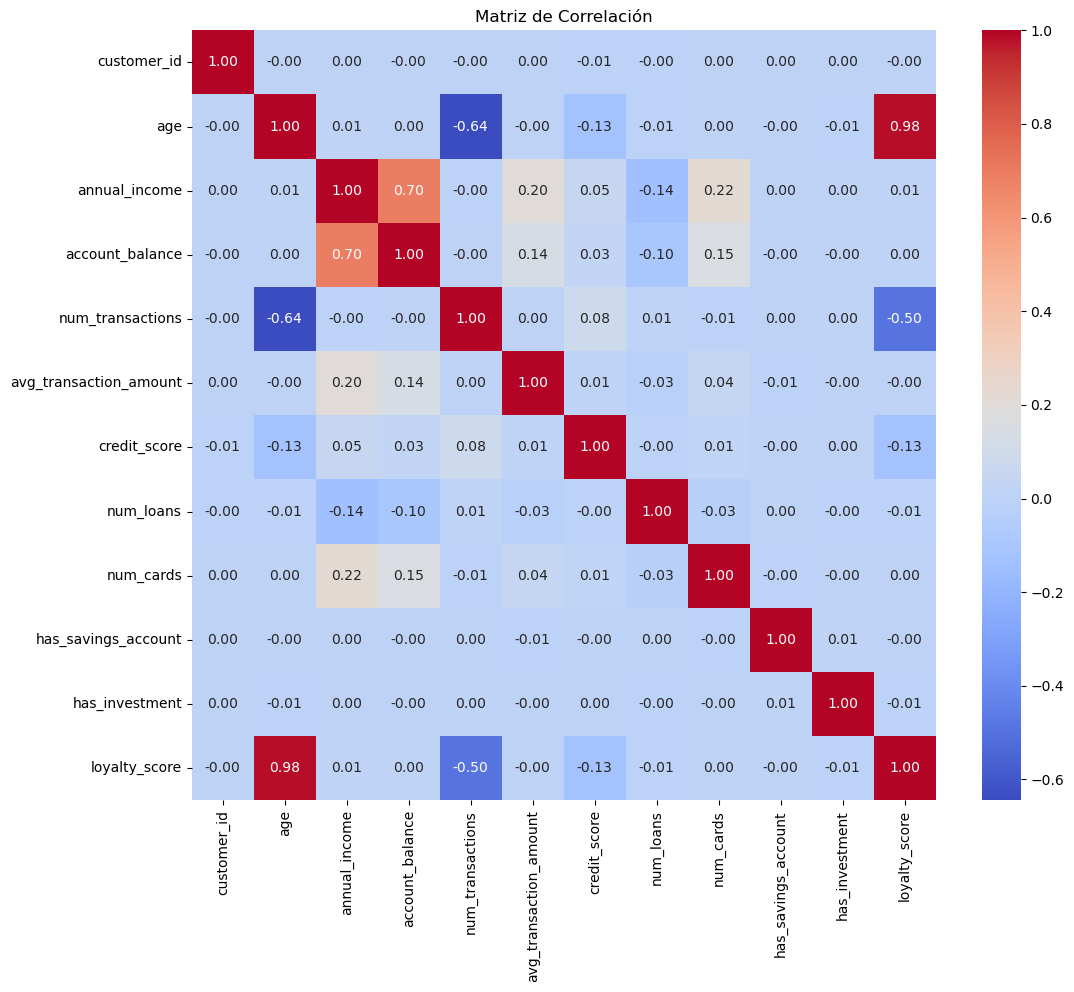

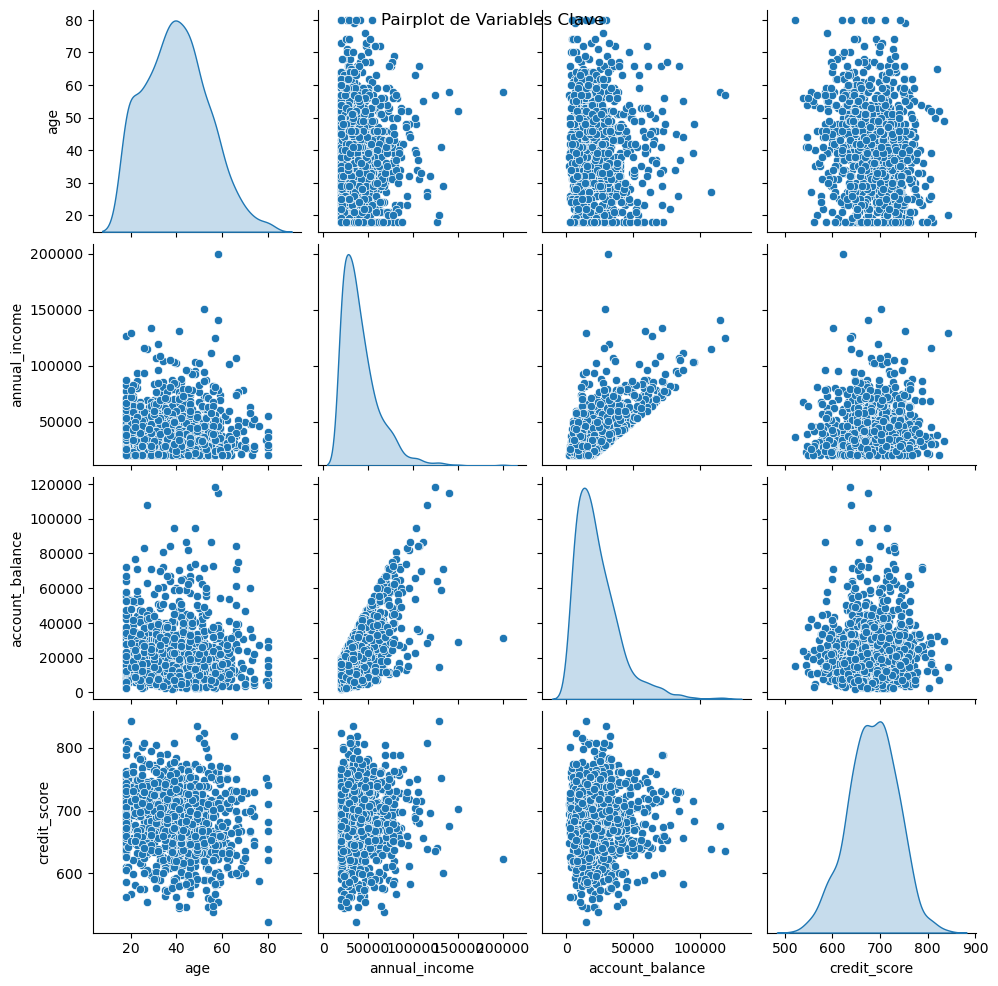

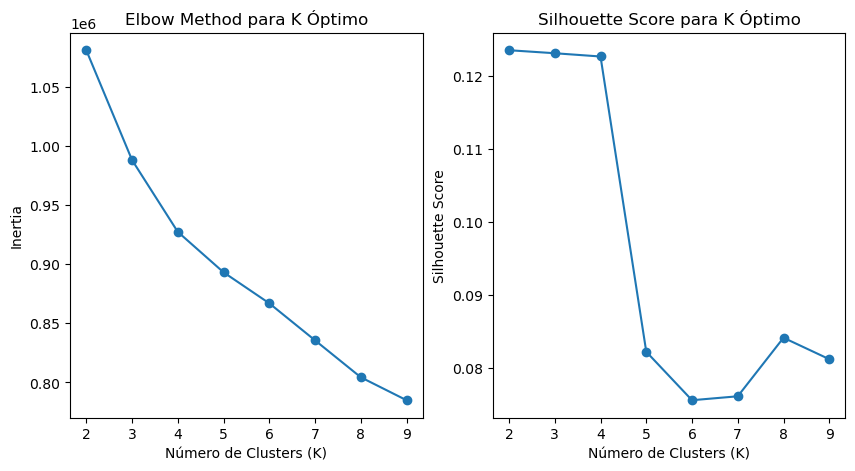


Distribución de Clientes por Cluster:
cluster
1    38300
0    32368
3    16371
2    12961
Name: count, dtype: int64


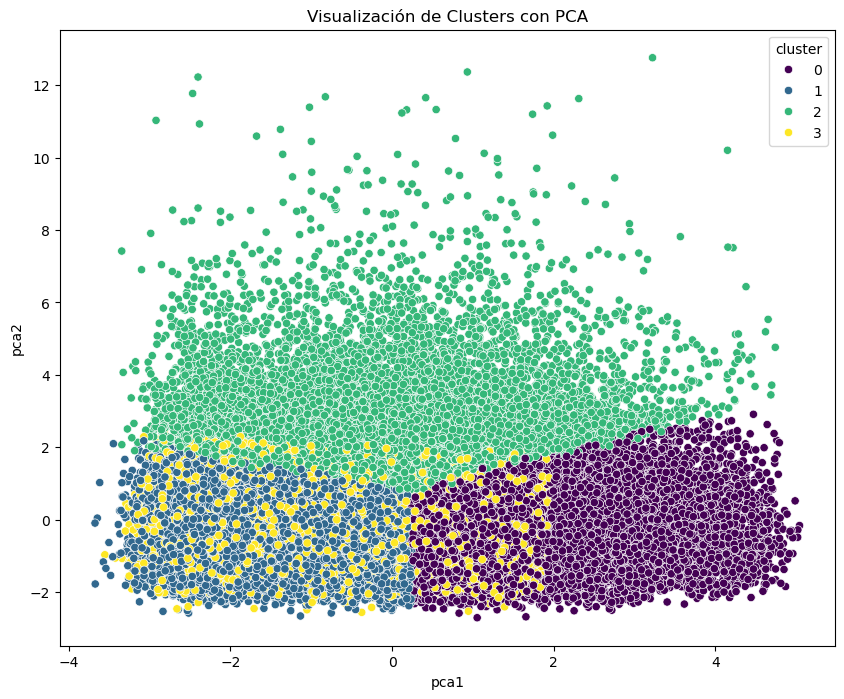


Perfiles Promedio por Cluster:
          age  annual_income  account_balance  num_transactions  \
cluster                                                           
0        1.00          -0.26            -0.25             -0.75   
1       -0.73          -0.30            -0.29              0.55   
2       -0.03           1.77             1.73              0.01   
3       -0.26          -0.19            -0.19              0.19   

         avg_transaction_amount  credit_score  num_loans  num_cards  \
cluster                                                               
0                         -0.09         -0.23       0.04      -0.08   
1                         -0.10          0.13       0.07      -0.10   
2                          0.61          0.13      -0.37       0.55   
3                         -0.06          0.04       0.03      -0.05   

         has_savings_account  has_investment  loyalty_score  
cluster                                                      
0             

In [2]:
import pandas as pd  # Para manipulación de DataFrames y datos estructurados
import numpy as np   # Para generación de datos sintéticos numéricos y operaciones matemáticas
import matplotlib.pyplot as plt  # Para visualizaciones básicas como gráficos de dispersión y elbow
import seaborn as sns  # Para gráficos avanzados y atractivos (e.g., heatmaps, pairplots)
from sklearn.preprocessing import StandardScaler  # Para escalar features numéricas (necesario en clustering)
from sklearn.cluster import KMeans  # Algoritmo principal para segmentación (K-Means)
from sklearn.decomposition import PCA  # Para reducción de dimensionalidad y visualización de clusters en 2D
from sklearn.metrics import silhouette_score  # Métrica para evaluar calidad de clusters (opcional para profesionalismo)
import warnings
warnings.filterwarnings('ignore')  # Ignorar warnings menores para salida limpia

# Paso 1: Generar un dataset sintético desde cero para segmentación de clientes bancarios
# Simularemos 100,000 clientes con más de 10 variables relevantes para banca.
# Variables clave para clustering por comportamiento:
# - customer_id: ID único (entero)
# - age: Edad (18-80 años)
# - gender: Género ('Male', 'Female', 'Other')
# - annual_income: Ingreso anual (USD, 20k-200k)
# - account_balance: Saldo en cuenta (0-500k)
# - num_transactions: Transacciones mensuales (0-100)
# - avg_transaction_amount: Monto promedio por transacción (50-5000 USD)
# - credit_score: Puntaje crediticio (300-850)
# - num_loans: Número de préstamos activos (0-5)
# - num_cards: Número de tarjetas (0-5)
# - has_savings_account: Cuenta de ahorros (0/1)
# - has_investment: Inversiones (0/1)
# - loyalty_score: Puntaje de lealtad (basado en antigüedad, 0-100)
# - region: Región geográfica ('North', 'South', 'East', 'West') - Para segmentación demográfica
# - preferred_channel: Canal preferido ('App', 'Branch', 'Online', 'ATM')
# No generamos target supervisado; clustering es no supervisado para descubrir segmentos.

def generate_banking_data(num_records=100000):
    """
    Genera dataset sintético de clientes bancarios para segmentación.
    - num_records: Número de registros (100,000 clientes).
    Retorna DataFrame con variables realistas para clustering.
    """
    np.random.seed(42)  # Reproducibilidad
    
    data = {}
    
    # ID único del cliente
    data['customer_id'] = np.arange(1, num_records + 1)
    
    # Edad: Distribución normal centrada en 40, std=15
    data['age'] = np.clip(np.random.normal(40, 15, num_records), 18, 80).astype(int)
    
    # Género: Distribución ponderada
    data['gender'] = np.random.choice(['Male', 'Female', 'Other'], num_records, p=[0.48, 0.48, 0.04])
    
    # Ingreso anual: Lognormal para simular distribución real (skewed)
    data['annual_income'] = np.clip(np.random.lognormal(mean=10.5, sigma=0.5, size=num_records), 20000, 200000).astype(int)
    
    # Saldo en cuenta: Correlacionado con ingreso (mayor ingreso → mayor saldo)
    data['account_balance'] = np.clip(data['annual_income'] * np.random.uniform(0.1, 1.0, num_records), 0, 500000).astype(int)
    
    # Transacciones mensuales: Poisson, más en jóvenes/digitales
    data['num_transactions'] = np.random.poisson(20 + (24 - data['age']/3), num_records)
    
    # Monto promedio por transacción: Correlacionado con ingreso
    data['avg_transaction_amount'] = np.clip(np.random.normal(data['annual_income']/1000, 100, num_records), 50, 5000)
    
    # Puntaje crediticio: Alto para ingresos altos, bajo para jóvenes
    data['credit_score'] = np.clip(np.random.normal(700 + (data['annual_income']/10000 - data['age']/2), 50, num_records), 300, 850).astype(int)
    
    # Número de préstamos: Bajo para bajos ingresos
    data['num_loans'] = np.random.poisson(1 + (data['annual_income'] < 50000)/2, num_records)
    data['num_loans'] = np.clip(data['num_loans'], 0, 5)
    
    # Número de tarjetas: Similar a préstamos
    data['num_cards'] = np.random.poisson(2 + (data['annual_income']/50000), num_records)
    data['num_cards'] = np.clip(data['num_cards'], 0, 5)
    
    # Cuenta de ahorros: Más probable en ingresos altos
    data['has_savings_account'] = np.random.choice([0, 1], num_records, p=[0.3, 0.7] if np.mean(data['annual_income']) > 50000 else [0.6, 0.4])
    
    # Inversiones: Solo para altos ingresos
    data['has_investment'] = np.random.choice([0, 1], num_records, p=[0.2, 0.8] if np.mean(data['annual_income']) > 100000 else [0.8, 0.2])
    
    # Puntaje de lealtad: Basado en edad y transacciones
    data['loyalty_score'] = np.clip(50 + data['age']/2 + data['num_transactions']/5, 0, 100).astype(int)
    
    # Región geográfica
    data['region'] = np.random.choice(['North', 'South', 'East', 'West'], num_records)
    
    # Canal preferido
    data['preferred_channel'] = np.random.choice(['App', 'Branch', 'Online', 'ATM'], num_records, p=[0.4, 0.2, 0.3, 0.1])
    
    df = pd.DataFrame(data)
    print(f"Dataset generado: {len(df)} registros con {len(df.columns)} variables.")
    return df

# Generar el dataset
bank_df = generate_banking_data(num_records=100000)

# Guardar como CSV (opcional)
bank_df.to_csv('bank_customers_segmentation.csv', index=False)

# Paso 2: Análisis Exploratorio de Datos (EDA)
# Resumen estadístico para entender distribución
print("\nEstadísticas descriptivas del dataset:")
print(bank_df.describe())

# Visualizar correlaciones (para identificar patrones)
numeric_cols = bank_df.select_dtypes(include=[np.number]).columns
corr_matrix = bank_df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

# Pairplot para variables clave (muestra pequeña para velocidad)
sns.pairplot(bank_df.sample(1000)[['age', 'annual_income', 'account_balance', 'credit_score']], diag_kind='kde')
plt.suptitle('Pairplot de Variables Clave')
plt.show()

# Paso 3: Preprocesamiento
# Codificar variables categóricas (One-Hot Encoding para gender, region, preferred_channel)
cat_cols = ['gender', 'region', 'preferred_channel']
bank_df = pd.get_dummies(bank_df, columns=cat_cols, drop_first=True)

# Escalar variables numéricas (K-Means es sensible a escalas)
num_cols = ['age', 'annual_income', 'account_balance', 'num_transactions', 'avg_transaction_amount', 
            'credit_score', 'num_loans', 'num_cards', 'has_savings_account', 'has_investment', 'loyalty_score']
scaler = StandardScaler()
bank_df[num_cols] = scaler.fit_transform(bank_df[num_cols])

# Seleccionar features para clustering (excluir ID)
X = bank_df.drop(columns=['customer_id'])

# Paso 4: Determinar número óptimo de clusters (K) con Elbow Method y Silhouette Score
inertia = []
silhouette_scores = []
k_range = range(2, 10)  # Probar de 2 a 9 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)  # Suma de cuadrados dentro de clusters
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Gráfico Elbow
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method para K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inertia')

# Gráfico Silhouette
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score para K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

# Elegir K óptimo (e.g., donde elbow se dobla o silhouette máximo; asumimos K=4 basado en típico)
optimal_k = 4  # Ajusta basado en gráficos

# Paso 5: Aplicar K-Means y Asignar Clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
bank_df['cluster'] = kmeans.fit_predict(X)

print("\nDistribución de Clientes por Cluster:")
print(bank_df['cluster'].value_counts())

# Paso 6: Visualización de Clusters con PCA (reducción a 2D para plot)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
bank_df['pca1'] = X_pca[:, 0]
bank_df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=bank_df, palette='viridis')
plt.title('Visualización de Clusters con PCA')
plt.show()

# Paso 7: Análisis de Clusters e Insights para Marketing Personalizado
# Perfil promedio por cluster
cluster_profiles = bank_df.groupby('cluster')[num_cols].mean().round(2)
print("\nPerfiles Promedio por Cluster:")
print(cluster_profiles)

# Sugerencias de marketing basado en clusters (lógica simple)
for cluster in range(optimal_k):
    profile = cluster_profiles.loc[cluster]
    st = f"\nCluster {cluster}: "
    if profile['annual_income'] > 0.5:  # Ingreso alto (escalado)
        st += "Clientes de alto ingreso. Ofrecer: Inversiones premium, tarjetas elite."
    elif profile['age'] < -0.5:  # Jóvenes (escalado negativo)
        st += "Clientes jóvenes. Ofrecer: Préstamos estudiantiles, app banking con rewards."
    elif profile['num_loans'] > 0.5:
        st += "Clientes con deudas. Ofrecer: Refinanciamiento, asesoría financiera."
    else:
        st += "Clientes estándar. Ofrecer: Cuentas de ahorros con bonos, promociones básicas."
    print(st)

print("\n¡Segmentación completada! K-Means agrupa clientes para marketing targeted.")
print("- Insights: Usa clusters para campañas: e.g., email personalizado por segmento.")
print("- Profesionalismo: En banca real, integra con CRM para automatizar ofertas.")